In [10]:
import pandas as pd 

df = pd.read_csv("results.csv")

In [11]:
df.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 49477 entries, 0 to 49476
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        49477 non-null  str    
 1   home_team   49477 non-null  str    
 2   away_team   49477 non-null  str    
 3   home_score  49409 non-null  float64
 4   away_score  49409 non-null  float64
 5   tournament  49477 non-null  str    
 6   city        49477 non-null  str    
 7   country     49477 non-null  str    
 8   neutral     49477 non-null  bool   
dtypes: bool(1), float64(2), str(6)
memory usage: 3.1 MB


In [13]:
df.describe()

,home_score,away_score
count,49409.000000,49409.000000
mean,1.757291,1.181890
std,1.774255,1.402027
min,0.000000,0.000000
25%,1.000000,0.000000
50%,1.000000,1.000000
75%,2.000000,2.000000
max,31.000000,21.000000


In [14]:
df.isnull().sum()

date           0
home_team      0
away_team      0
home_score    68
away_score    68
tournament     0
city           0
country        0
neutral        0
dtype: int64

In [15]:
df.dropna(subset=["home_score", "away_score"], inplace=True)

In [16]:
df.isnull().sum()

date          0
home_team     0
away_team     0
home_score    0
away_score    0
tournament    0
city          0
country       0
neutral       0
dtype: int64

In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 49409 entries, 0 to 49408
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        49409 non-null  str    
 1   home_team   49409 non-null  str    
 2   away_team   49409 non-null  str    
 3   home_score  49409 non-null  float64
 4   away_score  49409 non-null  float64
 5   tournament  49409 non-null  str    
 6   city        49409 non-null  str    
 7   country     49409 non-null  str    
 8   neutral     49409 non-null  bool   
dtypes: bool(1), float64(2), str(6)
memory usage: 3.1 MB


In [19]:
df.shape

(49409, 9)

In [20]:
df["result"] = df.apply(lambda row: "home_win" if row["home_score"] > row["away_score"] else ("away_win" if row["home_score"] < row["away_score"] else "draw"), axis=1)

In [21]:
df["result"].value_counts()


result
home_win    24215
away_win    13960
draw        11234
Name: count, dtype: int64

Matplotlib is building the font cache; this may take a moment.


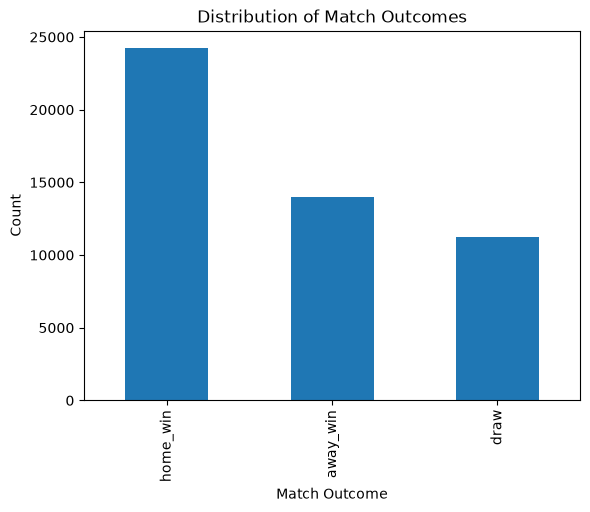

In [22]:
import matplotlib.pyplot as plt

df["result"].value_counts().plot(kind="bar")
plt.title("Distribution of Match Outcomes")
plt.xlabel("Match Outcome")
plt.ylabel("Count")
plt.show()

In [23]:
df["tournament"].value_counts().head(20)

tournament
Friendly                                18388
FIFA World Cup qualification             8771
UEFA Euro qualification                  2824
African Cup of Nations qualification     2327
FIFA World Cup                            968
Copa América                              869
African Cup of Nations                    845
AFC Asian Cup qualification               829
UEFA Nations League                       658
CECAFA Cup                                620
CFU Caribbean Cup qualification           606
Merdeka Tournament                        599
British Home Championship                 523
CONCACAF Nations League                   422
AFC Asian Cup                             421
Gold Cup                                  420
Gulf Cup                                  410
Island Games                              394
UEFA Euro                                 388
Asian Games                               368
Name: count, dtype: int64

In [24]:
df = df[df["tournament"] != "Friendly"]

In [25]:
df.shape

(31021, 10)

In [26]:
df["neutral"].value_counts()

neutral
False    20626
True     10395
Name: count, dtype: int64

In [27]:
df.to_csv("results_cleaned.csv", index=False)